In [ ]:
"""
Early stopping is a simple and effective regularization technique that monitors a model's performance on a validation dataset during training.
Instead of training for a fixed number of epochs, it automatically stops training when the validation metric no longer improves.
This helps prevent overfitting and saves computational resources.

Stops training before the model begins memorizing noise in the training data, improving generalization.
Selects the model from the epoch with the best validation metric instead of the final epoch.
Reduces training time by avoiding unnecessary epochs once performance has stabilized.
"""

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [4]:
# Load and Preprocess the Dataset

# if have not downloaded dataset uncomment this and use it
# (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# x_train = x_train / 255.0
# x_test = x_test / 255.0


import numpy as np
import struct
import os

def load_mnist_images(filename):
    with open(filename, 'rb') as f:
        magic, num, rows, cols = struct.unpack('>IIII', f.read(16))
        data = np.frombuffer(f.read(), dtype=np.uint8)
        return data.reshape(num, rows, cols)

def load_mnist_labels(filename):
    with open(filename, 'rb') as f:
        magic, num = struct.unpack('>II', f.read(8))
        data = np.frombuffer(f.read(), dtype=np.uint8)
        return data

data_dir = os.path.join('data', 'MNIST', 'raw')

x_train = load_mnist_images(os.path.join(data_dir, 'train-images-idx3-ubyte'))
y_train = load_mnist_labels(os.path.join(data_dir, 'train-labels-idx1-ubyte'))
x_test  = load_mnist_images(os.path.join(data_dir, 't10k-images-idx3-ubyte'))
y_test  = load_mnist_labels(os.path.join(data_dir, 't10k-labels-idx1-ubyte'))

# Normalize
x_train = x_train / 255.0
x_test  = x_test / 255.0


In [6]:
# Build the Neural Network

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [7]:
# Create the Early Stopping Callback

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


In [8]:
# Train the Model with Early Stopping

history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9180 - loss: 0.2873 - val_accuracy: 0.9508 - val_loss: 0.1627
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9628 - loss: 0.1291 - val_accuracy: 0.9657 - val_loss: 0.1180
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9731 - loss: 0.0888 - val_accuracy: 0.9707 - val_loss: 0.0962
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9800 - loss: 0.0655 - val_accuracy: 0.9724 - val_loss: 0.0902
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9854 - loss: 0.0492 - val_accuracy: 0.9747 - val_loss: 0.0837
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9881 - loss: 0.0387 - val_accuracy: 0.9743 - val_loss: 0.0864
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9900 - loss: 0.0315 - val_accuracy: 0.9747 - val_loss: 0.0900
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9931 - loss: 0.0231 - 

In [9]:
# Evaluate the Model

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9773 - loss: 0.0738
Test Loss: 0.0738
Test Accuracy: 0.9773


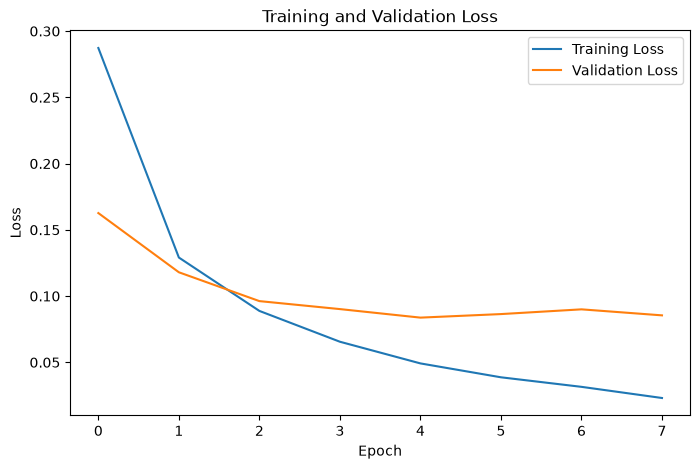

In [10]:
# Visualize the Training Process

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()